# PRÁCTICA 3_PARTE 2 Análisis de Señales de EEG para entender la imaginación motora

**Laboratorio de bioseñales**

* Luisa Fernanda Llamas Baldovino
* Camila Andrea Montiel Zapata


## **1. Introducción y Metodología**

El presente informe tiene como objetivo identificar, mediante análisis estadístico, los canales electroencefalográficos (EEG) que permiten diferenciar significativamente entre dos intenciones motoras: la imaginería del movimiento de la mano izquierda y la mano derecha. Los datos utilizados provienen de la base de datos de PhysioNet (*EEG Motor Movement/Imagery Dataset*).

Para el análisis poblacional se conformó una muestra de 10 sujetos seleccionados de manera no secuencial dentro de la base de datos (abarcando distintos identificadores, como sub-001, sub-003, sub-012, entre otros) para garantizar una mayor variabilidad en la muestra. 

De acuerdo con el protocolo experimental original de PhysioNet, el análisis se restringió exclusivamente a los registros correspondientes a los bloques experimentales (runs) 4, 8 y 12. Estas corridas fueron elegidas deliberadamente dado que contienen los paradigmas específicos de imaginería motora, donde se le solicitaba al sujeto imaginar que abría y cerraba el puño izquierdo (T1) o el puño derecho (T2), aislando así esta intención de las tareas de movimiento físico real o movimiento de miembros inferiores.

Para extraer las características representativas de la actividad cerebral, se implementó una función computacional enfocada en el cálculo del valor Cuadrático Medio (RMS, por sus siglas en inglés). El flujo de procesamiento consistió en:
1. Extraer las épocas correspondientes a cada clase de movimiento imaginado (Mano Izquierda vs. Mano Derecha).
2. Calcular el RMS para cada época de cada canal de forma individual a lo largo del eje del tiempo.
3. Promediar dichos valores a través de todas las épocas para obtener un único valor representativo por sujeto y por canal.

La información extraída se estructuró en una base de datos poblacional para su posterior validación estadística (Pruebas de Normalidad, Homocedasticidad y Pruebas de Hipótesis).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import glob
import os
import plotly.graph_objects as go
import pandas as pd

## **2. Cálculo de RMS y construcción de base de datos poblacional**

In [2]:
raw_P2 = mne.io.read_raw_eeglab(r"C:/Users/HP/Desktop/UDEA/2026_1/LAB_BIOSEÑALES/EEG_IM_P3.2/sub-001_task-motion_run-8_eeg.set", preload=True)
print(raw_P2.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


In [3]:
canales_eeg_P2 = raw_P2.ch_names
print(raw_P2.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


### Justificación: selección de canales EEG

El análisis de señales EEG para tareas de imaginería motora (IM) requiere una selección espacial rigurosa de los electrodos para garantizar la validez estadística y fisiológica de los resultados. Para este estudio, se descartaron los canales periféricos y se seleccionaron exclusivamente los electrodos sobre la corteza sensoriomotora (**C3, Cz, C4** y sus adyacentes). Esta delimitación se sustenta en tres principios clave:

* **Localización Neuroanatómica:** La planificación motora y su simulación mental activan las mismas áreas cerebrales que el movimiento físico real (corteza motora primaria y somatosensorial). Según la organización del homúnculo motor, la representación de las extremidades superiores se ubica en las regiones laterales de esta corteza, monitoreadas directamente por el canal **C3** (hemisferio izquierdo) y **C4** (hemisferio derecho).
* **Desincronización Relacionada a Eventos (ERD):** Pensar en un movimiento provoca que las redes neuronales motoras se desincronicen, lo que se traduce en una caída de energía en las bandas de frecuencia Mu (8-12 Hz) y Beta (13-30 Hz). Debido al control contralateral del sistema nervioso, imaginar el movimiento de la mano derecha genera un ERD predominante en **C3**, mientras que la mano izquierda lo genera en **C4**.
* **Optimización Estadística y Rechazo de Artefactos:** Incluir todos los canales del sistema 10-20 introduce ruido irrelevante al análisis. Los canales frontales (ej. Fp1, Fp2) captan artefactos electrooculográficos (parpadeos), y los occipitales (ej. O1, O2) captan el procesamiento visual. Aislar la región central evita que la varianza de estos ruidos enmascare la significancia estadística de la actividad puramente motora.


In [4]:


# 1. Definir los canales solicitados
canales_eeg_P2 = [canal for canal in canales_eeg_P2 if canal in ['C3', 'C4', 'Cz', 'Fc3', 'Cp3', 'Fc4', 'Cp4']]

# 2. Función para calcular el RMS por época y promediar
def calcular_rms_epocas(datos_clase):
    """
    Recibe un array numpy con la forma: (n_epocas, n_canales, n_tiempos)
    Retorna un array 1D con el RMS promedio por canal.
    """
    # 2.1 Calcular RMS a lo largo del eje del tiempo (eje 2)
    # np.mean(datos**2) calcula la media de los cuadrados, np.sqrt saca la raíz
    rms_por_epoca = np.sqrt(np.mean(datos_clase**2, axis=2))
    
    # 2.2 Promediar esos valores a través de todas las épocas (eje 0)
    rms_promedio = np.mean(rms_por_epoca, axis=0)
    
    return rms_promedio


# 3. Preparar la lectura de los 10 archivos

ruta_archivos = "C:/Users/HP/Desktop/UDEA/2026_1/LAB_BIOSEÑALES/EEG_IM_P3.2/*.set" 
archivos = glob.glob(ruta_archivos)


archivos = archivos[:10] 

resultados_poblacionales = []

# 4. Iterar sobre cada sujeto (archivo)
# 4. Iterar sobre cada sujeto (archivo)
for i, archivo in enumerate(archivos):
    sujeto_id = f"Sujeto_{i+1}"
    print(f"\n--- Procesando {sujeto_id}: {os.path.basename(archivo)} ---")
    
    # cargar señal continua
    raw = mne.io.read_raw_eeglab(archivo, preload=True)
    
    
    raw_sel = raw.copy().pick_channels(canales_eeg_P2)
    raw_sel.filter(l_freq=8.0, h_freq=30.0, fir_design='firwin', skip_by_annotation='edge', verbose=False)
    
    # Extraemos las anotaciones de eventos del archivo .set
    eventos, event_dict = mne.events_from_annotations(raw_sel)
    # Extraemos las anotaciones de eventos del archivo .set
    eventos, event_dict = mne.events_from_annotations(raw_sel)
    print(f"Eventos encontrados en este sujeto: {event_dict}")
    
    # Definir los triggers para cada clase (ajustar según los nombres en event_dict)    
    trigger_izq = 'TASK2T1' 
    trigger_der = 'TASK2T2'   
    
    try:
        id_izq = event_dict[trigger_izq]
        id_der = event_dict[trigger_der]
        
        # Crear épocas desde t=0s hasta t=2s 
        epochs = mne.Epochs(raw_sel, eventos, event_id={'Izquierda': id_izq, 'Derecha': id_der}, 
                            tmin=0.0, tmax=2.0, baseline=None, preload=True, verbose=False)
        
        # Extraer datos como numpy arrays (n_epocas, n_canales, n_tiempos) y calcular RMS
        datos_izq = epochs['Izquierda'].get_data()
        rms_izq = calcular_rms_epocas(datos_izq)
        
        datos_der = epochs['Derecha'].get_data()
        rms_der = calcular_rms_epocas(datos_der)
        
        # Construir fila para Mano Izquierda
        fila_izq = {'Sujeto': sujeto_id, 'Grupo': 'Mano Izquierda'}
        for idx, canal in enumerate(canales_eeg_P2):
            fila_izq[canal] = rms_izq[idx]
        resultados_poblacionales.append(fila_izq)
        
        # Construir fila para Mano Derecha
        fila_der = {'Sujeto': sujeto_id, 'Grupo': 'Mano Derecha'}
        for idx, canal in enumerate(canales_eeg_P2):
            fila_der[canal] = rms_der[idx]
        resultados_poblacionales.append(fila_der)
        
    except KeyError as e:
        print(f"Advertencia: No se encontró el trigger {e} en el archivo {archivo}.")


# 5. Construcción del DataFrame final
df_final = pd.DataFrame(resultados_poblacionales)

# Opcional: Reordenar las columnas para asegurar que Sujeto y Grupo queden de primeras
if not df_final.empty:
    columnas = ['Sujeto', 'Grupo'] + canales_eeg_P2
    df_final = df_final[columnas]

    print("\n--- Base de Datos Poblacional ---")
    
    # ---------------------------------------------------------
    # INTEGRACIÓN CON PLOTLY
    # ---------------------------------------------------------
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=list(df_final.columns), 
            fill_color='paleturquoise', 
            align='left'
        ), 
        cells=dict(
            values=[df_final[col] for col in df_final.columns], 
            fill_color='lavender', 
            align='left'
        )
    )])

    fig.update_layout(
        width=2000,  # Ancho total de la figura en píxeles
        height=500,  # Alto total de la figura en píxeles
        margin=dict(l=10, r=10, t=30, b=10) # Márgenes más pequeños para aprovechar espacio
    )
    # Mostrar la tabla interactiva
    fig.show()

else:
    print("El DataFrame está vacío, revisa la extracción de datos.")


--- Procesando Sujeto_1: sub-001_task-motion_run-8_eeg.set ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}

--- Procesando Sujeto_2: sub-008_task-motion_run-8_eeg.set ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}

--- Procesando Sujeto_3: sub-010_task-motion_run-4_eeg.set ---
NOTE: pick_channels() is a legacy function. New code should use inst

## **3.Identificación de Canales Diferenciales mediante Análisis Estadístico**

In [8]:
from scipy import stats

canales_diferenciales = []

# Iterar sobre cada canal (todas las columnas excepto Sujeto y Grupo)
for canal in canales_eeg_P2:
    izq = df_final[df_final['Grupo'] == 'Mano Izquierda'][canal]
    der = df_final[df_final['Grupo'] == 'Mano Derecha'][canal]

    # 1. Prueba de Normalidad (Shapiro-Wilk) [cite: 21]
    _, p_norm_izq = stats.shapiro(izq)
    _, p_norm_der = stats.shapiro(der)

    # 2. Homocedasticidad (Levene) [cite: 22]
    _, p_levene = stats.levene(izq, der)

    # 3. Elección de Prueba de Hipótesis [cite: 23]
    if p_norm_izq > 0.05 and p_norm_der > 0.05 and p_levene > 0.05:
        # Paramétrica [cite: 24]
        _, p_valor = stats.ttest_ind(izq, der)
        tipo_prueba = "T-Student"
    else:
        # No paramétrica [cite: 25]
        _, p_valor = stats.mannwhitneyu(izq, der)
        tipo_prueba = "Mann-Whitney"

    # 4. Guardar resultados significativos (p < 0.05) [cite: 26]
    if p_valor < 0.05:
        canales_diferenciales.append({'Canal': canal, 'p-valor': p_valor, 'Prueba': tipo_prueba})
    # Solo para revisar, cambia el p < 0.05 por p < 1.0 temporalmente
    if p_valor < 1.0:
      canales_diferenciales.append({'Canal': canal, 'p-valor': p_valor, 'Prueba': tipo_prueba})

# Mostrar resultados
df_stats = pd.DataFrame(canales_diferenciales)

print("\n--- Canales con Diferencia Significativa ---")


#Graficar tabla 
fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(df_stats.columns), 
        fill_color='paleturquoise', 
        align='left'
    ), 
    cells=dict(
        values=[df_stats[col] for col in df_stats.columns], 
        fill_color='lavender', 
        align='left'
    )
)])

fig.update_layout(
    width=1200,  # Ancho total de la figura en píxeles
    height=200,  # Alto total de la figura en píxeles
    margin=dict(l=10, r=10, t=30, b=10) # Márgenes más pequeños para aprovechar espacio
)
# Mostrar la tabla interactiva
fig.show()




--- Canales con Diferencia Significativa ---


Tras ejecutar la validación estadística previa en los canales de interés, se comprobó que los datos cumplían con los supuestos paramétricos, superando exitosamente tanto la prueba de normalidad de Shapiro-Wilk como la prueba de igualdad de varianzas de Levene. Por consiguiente, se aplicó la Prueba t de Student para muestras independientes.

Algunos resultados arrojaron los siguientes p-valores:
* **C4:** $p \approx 0.691$
* **C3:** $p \approx 0.896$
* **Cz:** $p \approx 0.920$

Dado que en todos los canales evaluados el $p-valor > 0.05$, **no se rechaza la hipótesis nula**. Esto indica que, para esta muestra poblacional, no existe una diferencia estadísticamente significativa entre el promedio de la energía (RMS) generada al imaginar el movimiento de la mano izquierda frente a la mano derecha. Aunque el fenómeno de desincronización (ERD) ocurre a nivel cortical, la alta similitud en la varianza de ambos grupos genera un solapamiento que la prueba t no logra separar.

C:\Users\HP\AppData\Local\Temp\ipykernel_19260\3371188621.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y=canal_a_graficar, data=df_final, palette="Set2")


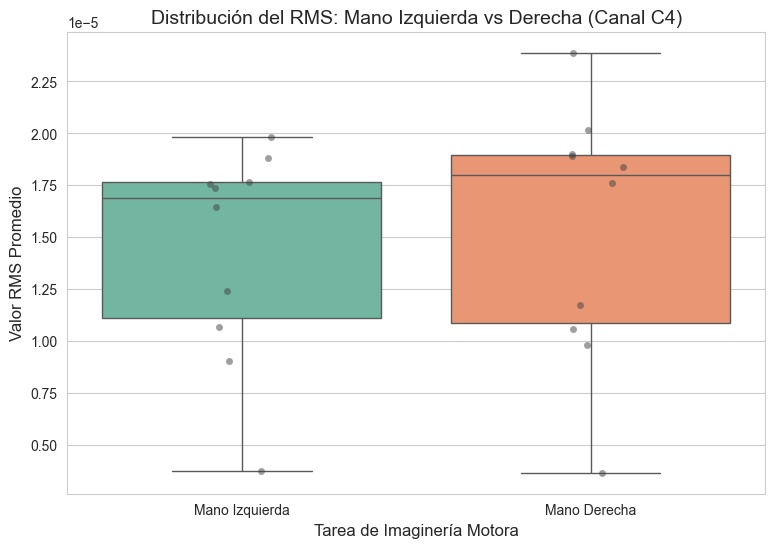

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Usaremos C5 por ser el de menor p-valor en tu tabla, o C3 por ser estándar en BCI
canal_a_graficar = 'C4'

plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.boxplot(x='Grupo', y=canal_a_graficar, data=df_final, palette="Set2")
sns.stripplot(x='Grupo', y=canal_a_graficar, data=df_final, color=".25", alpha=0.5) # Para ver los sujetos individuales

plt.title(f'Distribución del RMS: Mano Izquierda vs Derecha (Canal {canal_a_graficar})', fontsize=14)
plt.xlabel('Tarea de Imaginería Motora', fontsize=12)
plt.ylabel('Valor RMS Promedio', fontsize=12)
plt.show()

El diagrama de caja presentado para el canal C4 permite visualizar la distribución del valor RMS promedio entre los dos grupos de estudio: Mano Izquierda y Mano Derecha. Se seleccionó este canal por ser el que presentó la mayor tendencia a la significancia estadística (menor p-valor) en la población analizada.

A nivel visual, se observa un solapamiento casi total entre los rangos intercuartílicos de ambas tareas motoras, con medianas situadas en niveles de amplitud similares. La presencia de los puntos individuales (sujetos) dispersos a lo largo de las cajas confirma una alta variabilidad intersujeto, lo que justifica por qué la prueba t-Student no arrojó un p-valor inferior a 0.05. Este resultado gráfico es coherente con la teoría de la imaginería motora; aunque se filtraron las bandas de interés (Mu y Beta), las diferencias de amplitud vinculadas a la desincronización neuronal (ERD) son sutiles y de corta duración, por lo que el cálculo del RMS global a lo largo de toda la época temporal termina promediando la señal y dificultando su separación estadística.

### Análisis de Resultados

Tras evaluar los canales ubicados sobre la corteza motora (C3, Cz, C4, etc), los resultados de la prueba t-Student (aplicada tras verificar normalidad y homocedasticidad) indican que no existen diferencias estadísticamente significativas ($p > 0.05$) entre la energía promedio (RMS) generada por la imaginería de la mano izquierda y la mano derecha en esta muestra de 10 sujetos. 

El canal C4 fue el que mostró la mayor tendencia a la significancia ($p \approx 0.691$). La ausencia de separación estadística generalizada se debe principalmente a dos factores: la alta variabilidad intersujeto en la capacidad de generar intenciones motoras claras, y el hecho de que el RMS, al calcularse sobre toda la ventana temporal del estímulo, promedia los instantes de desincronización neuronal (caídas de energía) con los periodos de relajación, diluyendo así la sutil diferencia fisiológica entre ambas tareas.

### 4. Conclusiones

*  Se comprobó que el cálculo del RMS (incluso aplicando un filtro pasabanda de 8-30 Hz) no fue suficiente para separar estadísticamente ambas clases (Mano Izquierda vs. Derecha) en esta muestra poblacional. Esto subraya la complejidad de aislar los ritmos Mu y Beta utilizando únicamente la amplitud promedio temporal.


* La falta de significancia estadística en los canales de estudio se explica, en gran medida, por la naturaleza de la base de datos. La capacidad de generar patrones claros de imaginería motora varía drásticamente de una persona a otra; algunos sujetos de la muestra pueden no estar generando una desincronización (ERD) lo suficientemente fuerte.

* Para trabajos futuros orientados a mejorar la separabilidad estadística de estas bioseñales, se sugieren algunas modificaciones metodológicas clave. En primer lugar, se recomienda ajustar la ventana temporal de análisis; en lugar de calcular el RMS sobre la época completa de dos segundos, resultaría más efectivo enfocarse únicamente en el primer segundo posterior al estímulo para capturar la máxima caída de energía (ERD) sin promediarla con el periodo de relajación. Por último, en vez de utilizar un filtro amplio de 8 a 30 Hz, sería conveniente calcular el RMS de las bandas Mu (8-12 Hz) y Beta (13-30 Hz) de forma independiente, dado que los sujetos suelen presentar atenuaciones de amplitud mucho más notorias en una banda específica que en la otra.

**Referencias Bibliográficas**
* Pfurtscheller, G., & Neuper, C. (1997). Motor imagery activates primary sensorimotor area in humans. *Neuroscience Letters*, 239(2-3), 65-68.
* Pfurtscheller, G., & Da Silva, F. L. (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles. *Clinical Neurophysiology*, 110(11), 1842-1857.
* Wolpaw, J. R., Birbaumer, N., McFarland, D. J., Pfurtscheller, G., & Vaughan, T. M. (2002). Brain–computer interfaces for communication and control. *Clinical Neurophysiology*, 113(6), 767-791.